## Análisis de Churn con Gradient Boosting y Stacking Ensemble

**Autor:** Matias Damian Gutierrez
**Fecha:** 2025  
**Objetivo:** Comparar algoritmos de Gradient Boosting y técnicas de ensamble para predecir churn bancario.


In [2]:
# ============================================================================
# 1. CONFIGURACIÓN E IMPORTACIÓN DE BIBLIOTECAS
# ============================================================================

# Supresión de advertencias
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas fundamentales (como solicitaste)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos para gráficos
plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Scikit-learn (ensemble methods y utilidades básicas)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, classification_report,
                           confusion_matrix, roc_curve)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Gradient Boosting Libraries (como solicitaste)
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Optimización bayesiana (Optuna)
import optuna

print("✅ Todas las bibliotecas cargadas correctamente")
print(f"Versiones: Pandas {pd.__version__}, NumPy {np.__version__}")
print(f"XGBoost v{xgb.__version__}, LightGBM v{lgb.__version__}, CatBoost v{cb.__version__}")

✅ Todas las bibliotecas cargadas correctamente
Versiones: Pandas 2.3.3, NumPy 2.3.4
XGBoost v3.1.2, LightGBM v4.6.0, CatBoost v1.2.8


Explicación:
Esta sección importa todas las bibliotecas necesarias. Las más importantes son:

pandas/numpy: Manipulación de datos

matplotlib/seaborn: Visualizaciones

scikit-learn: Algoritmos ML y métricas

xgboost/lightgbm/catboost: Algoritmos de Gradient Boosting

optuna: Optimización bayesiana de hiperparámetros



### 2. CARGA Y ANÁLISIS EXPLORATORIO

En esta sección cargamos los datos y realizamos un análisis exploratorio inicial para entender la distribución y características del dataset.


2. CARGA Y ANÁLISIS EXPLORATORIO DE DATOS
📊 Dataset cargado: 10000 filas × 14 columnas

📋 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)


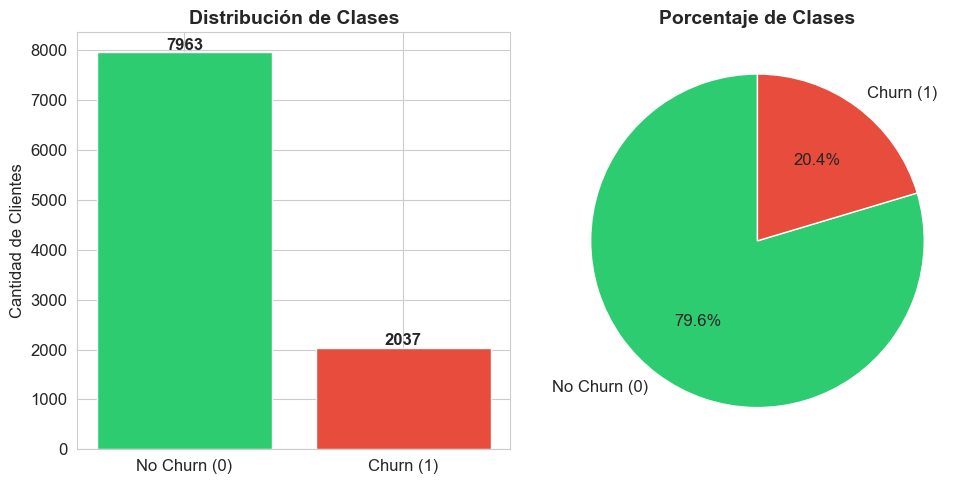


📈 Estadísticas descriptivas de variables numéricas:
        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

       EstimatedSalary  
count     10000.000000  
mean     100090.239881  
std       57510.492818  
min          11.580000  
25%       51002.110000  
50%      100193.915000  
75%      149388.247500  
max      199992.4

In [3]:
# ============================================================================
# 2. CARGA Y ANÁLISIS EXPLORATORIO DE DATOS
# ============================================================================

print("\n" + "="*70)
print("2. CARGA Y ANÁLISIS EXPLORATORIO DE DATOS")
print("="*70)

# Cargar datos
df = pd.read_csv('Churn_Modelling.csv')
print(f"📊 Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")

# Mostrar información básica
print("\n📋 Información del dataset:")
print(df.info())

# Mostrar primeras filas (SIN usar .style para evitar problemas con Jinja2)
print("\n🔍 Primeras 5 filas del dataset:")
print(df.head())

# Análisis de la variable objetivo
print("\n🎯 Distribución de la variable objetivo (Exited):")
target_dist = df['Exited'].value_counts()
print(f"  • Clase 0 (No Churn): {target_dist[0]} muestras ({target_dist[0]/len(df)*100:.1f}%)")
print(f"  • Clase 1 (Churn):    {target_dist[1]} muestras ({target_dist[1]/len(df)*100:.1f}%)")

# Gráfico de distribución de clases
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
bars = plt.bar(['No Churn (0)', 'Churn (1)'], target_dist.values, color=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Clases', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Clientes')
for bar, count in zip(bars, target_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(count), ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie(target_dist.values, labels=['No Churn (0)', 'Churn (1)'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Porcentaje de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas (SIN .style)
print("\n📈 Estadísticas descriptivas de variables numéricas:")
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
print(df[numeric_cols].describe())

In [4]:
# ============================================================================
# 3. PREPROCESAMIENTO DE DATOS
# ============================================================================

print("\n" + "="*70)
print("3. PREPROCESAMIENTO DE DATOS")
print("="*70)

def preprocess_data(df):
    """
    Función para preprocesar los datos
    """
    # Crear copia para no modificar el original
    df_processed = df.copy()
    
    # 1. Eliminar columnas no informativas
    columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
    df_processed = df_processed.drop(columns_to_drop, axis=1)
    
    # 2. Codificar variables categóricas manualmente (sin LabelEncoder)
    # Gender: Male=1, Female=0
    df_processed['Gender'] = df_processed['Gender'].map({'Male': 1, 'Female': 0})
    
    # 3. One-hot encoding manual para Geography (sin get_dummies)
    for country in df_processed['Geography'].unique():
        df_processed[f'Geography_{country}'] = (df_processed['Geography'] == country).astype(int)
    
    # Eliminar la columna original de Geography
    df_processed = df_processed.drop('Geography', axis=1)
    
    # 4. Separar features y target
    X = df_processed.drop('Exited', axis=1)
    y = df_processed['Exited']
    
    print(f"✅ Datos procesados: {X.shape[1]} features, {len(y)} muestras")
    return X, y

# Aplicar preprocesamiento
X, y = preprocess_data(df)

# División train-test (80-20)
print("\n📊 División Train-Test (80-20):")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  • Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  • Test:  {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Escalado de características
print("\n⚖️  Escalando características...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Escalado completado")


3. PREPROCESAMIENTO DE DATOS
✅ Datos procesados: 12 features, 10000 muestras

📊 División Train-Test (80-20):
  • Train: 8000 muestras (80.0%)
  • Test:  2000 muestras (20.0%)

⚖️  Escalando características...
✅ Escalado completado


In [5]:
# ============================================================================
# 4. FUNCIÓN DE EVALUACIÓN DE MODELOS
# ============================================================================

print("\n" + "="*70)
print("4. FUNCIÓN DE EVALUACIÓN DE MODELOS")
print("="*70)

def evaluate_model(name, model, X_test, y_test, show_plots=True):
    """
    Evalúa un modelo con múltiples métricas y visualizaciones
    """
    print(f"\n{'='*50}")
    print(f"📊 EVALUACIÓN: {name}")
    print('='*50)
    
    # Predicciones
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Métricas básicas
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
    }
    
    if y_pred_proba is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_test, y_pred_proba)
    
    # Mostrar métricas
    print("\n📈 Métricas de evaluación:")
    for metric_name, metric_value in metrics.items():
        print(f"  • {metric_name}: {metric_value:.4f}")
    
    # Reporte de clasificación
    print("\n📋 Reporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    
    # Visualizaciones si se solicitan
    if show_plots and y_pred_proba is not None:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'Evaluación: {name}', fontsize=14, fontweight='bold')
        
        # 1. Matriz de confusión
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Matriz de Confusión')
        axes[0].set_xlabel('Predicción')
        axes[0].set_ylabel('Real')
        
        # 2. Curva ROC
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, 
                    label=f'AUC = {roc_auc:.3f}')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Curva ROC')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)
        
        # 3. Distribución de probabilidades
        axes[2].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, 
                    color='green', label='No Churn', density=True)
        axes[2].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, 
                    color='red', label='Churn', density=True)
        axes[2].axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
        axes[2].set_xlabel('Probabilidad de Churn')
        axes[2].set_ylabel('Densidad')
        axes[2].set_title('Distribución de Probabilidades')
        axes[2].legend()
        
        plt.tight_layout()
        plt.show()
    
    return metrics


4. FUNCIÓN DE EVALUACIÓN DE MODELOS



5. RANDOM FOREST - MODELO BASELINE
🌲 Entrenando Random Forest...

📊 EVALUACIÓN: Random Forest

📈 Métricas de evaluación:
  • Accuracy: 0.8400
  • Precision: 0.5986
  • Recall: 0.6486
  • F1-Score: 0.6226
  • ROC-AUC: 0.8625

📋 Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.91      0.89      0.90      1593
       Churn       0.60      0.65      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



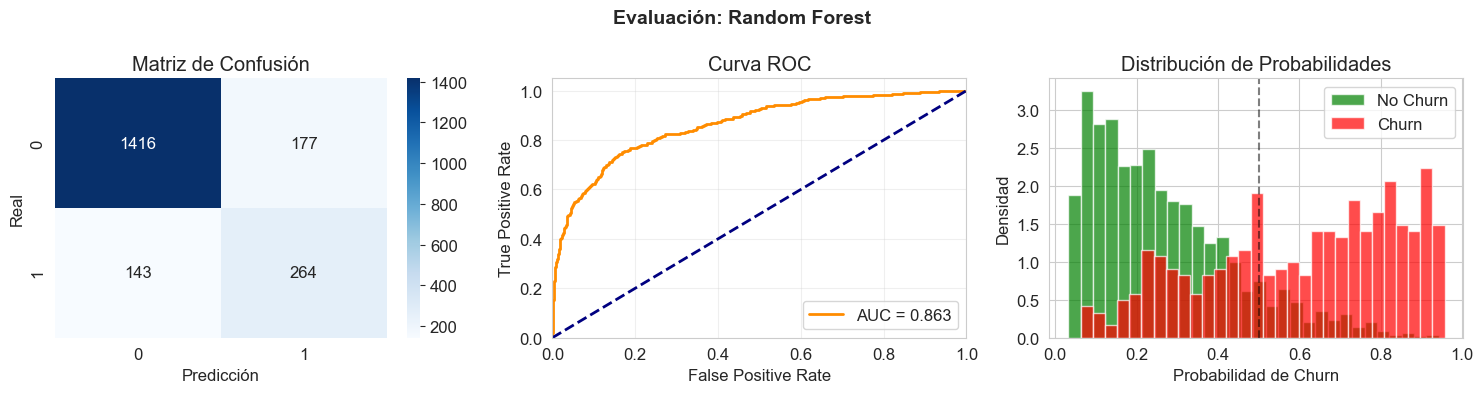

In [6]:
# ============================================================================
# 5. RANDOM FOREST (BASELINE PARA COMPARACIÓN)
# ============================================================================

print("\n" + "="*70)
print("5. RANDOM FOREST - MODELO BASELINE")
print("="*70)

# Importamos solo lo necesario para Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

print("🌲 Entrenando Random Forest...")
rf_model.fit(X_train_scaled, y_train)

rf_metrics = evaluate_model("Random Forest", rf_model, X_test_scaled, y_test)


6. XGBOOST CON GRID SEARCH
🔍 Configurando Grid Search para XGBoost...
🚀 Ejecutando Grid Search (esto puede tomar unos minutos)...
✅ Grid Search completado
🏆 Mejores parámetros encontrados:
  • colsample_bytree: 0.8
  • learning_rate: 0.1
  • max_depth: 3
  • n_estimators: 100
  • subsample: 0.8
📈 Mejor score (CV ROC-AUC): 0.8631

📊 EVALUACIÓN: XGBoost (Grid Search)

📈 Métricas de evaluación:
  • Accuracy: 0.8710
  • Precision: 0.8143
  • Recall: 0.4742
  • F1-Score: 0.5994
  • ROC-AUC: 0.8686

📋 Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.88      0.97      0.92      1593
       Churn       0.81      0.47      0.60       407

    accuracy                           0.87      2000
   macro avg       0.85      0.72      0.76      2000
weighted avg       0.87      0.87      0.86      2000



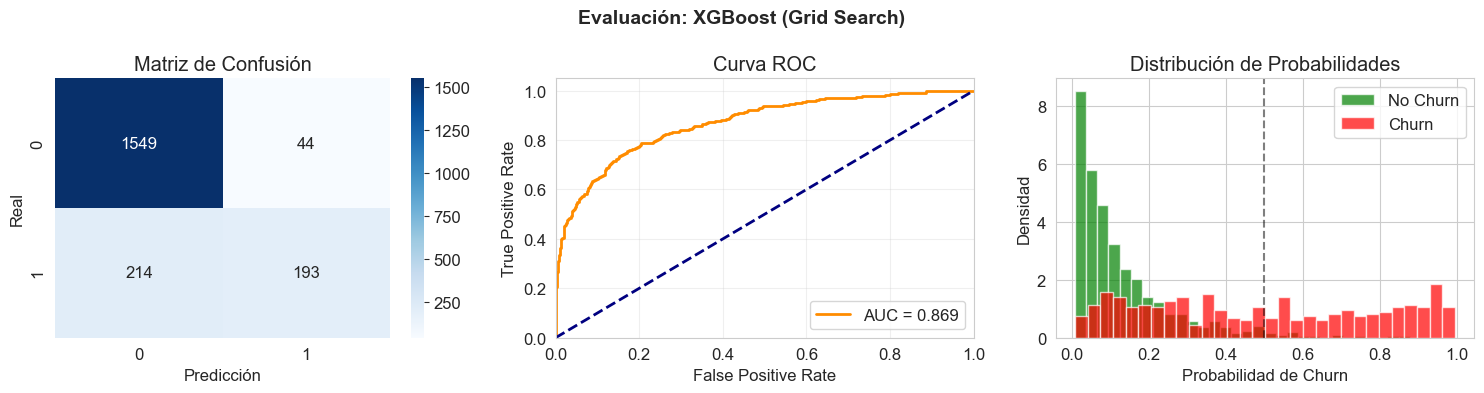

In [7]:
# ============================================================================
# 6. XGBOOST CON GRID SEARCH
# ============================================================================

print("\n" + "="*70)
print("6. XGBOOST CON GRID SEARCH")
print("="*70)

# Grid Search para XGBoost
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print("🔍 Configurando Grid Search para XGBoost...")
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0  # Cambiado a 0 para menos output
)

print("🚀 Ejecutando Grid Search (esto puede tomar unos minutos)...")
xgb_grid.fit(X_train_scaled, y_train)

print(f"✅ Grid Search completado")
print(f"🏆 Mejores parámetros encontrados:")
for param, value in xgb_grid.best_params_.items():
    print(f"  • {param}: {value}")
print(f"📈 Mejor score (CV ROC-AUC): {xgb_grid.best_score_:.4f}")

# Evaluar modelo optimizado
xgb_metrics = evaluate_model("XGBoost (Grid Search)", xgb_grid.best_estimator_, X_test_scaled, y_test)

[I 2026-01-12 00:36:39,682] A new study created in memory with name: XGBoost_Optimization



7. OPTUNA - OPTIMIZACIÓN BAYESIANA

🎯 OPTUNA vs Grid Search:
• Grid Search: Prueba todas las combinaciones (exhaustivo pero lento)
• Optuna: Usa optimización bayesiana (inteligente y eficiente)
• Más rápido para espacios de búsqueda grandes

🚀 Iniciando optimización con Optuna (50 trials)...


Best trial: 0. Best value: 0.829671:   2%|▏         | 1/50 [00:01<01:15,  1.55s/it]

[I 2026-01-12 00:36:41,352] Trial 0 finished with value: 0.8296713133946216 and parameters: {'max_depth': 7, 'learning_rate': 0.15594138152795553, 'n_estimators': 426, 'subsample': 0.888818758048056, 'colsample_bytree': 0.8718896601555257, 'reg_alpha': 0.527319010408361, 'reg_lambda': 0.00012592192938481474, 'min_child_weight': 9}. Best is trial 0 with value: 0.8296713133946216.


Best trial: 1. Best value: 0.86401:   4%|▍         | 2/50 [00:02<00:45,  1.07it/s] 

...

[I 2026-01-12 00:37:45,210] Trial 47 finished with value: 0.8618508413601814 and parameters: {'max_depth': 3, 'learning_rate': 0.01317564608805402, 'n_estimators': 364, 'subsample': 0.8451794772118251, 'colsample_bytree': 0.6387605078418557, 'reg_alpha': 0.0280789485786429, 'reg_lambda': 6.031532786913197e-08, 'min_child_weight': 2}. Best is trial 28 with value: 0.8649675842413783.


Best trial: 28. Best value: 0.864968:  98%|█████████▊| 49/50 [01:06<00:01,  1.62s/it]

[I 2026-01-12 00:37:46,717] Trial 48 finished with value: 0.8638341954232004 and parameters: {'max_depth': 5, 'learning_rate': 0.010940458957449667, 'n_estimators': 281, 'subsample': 0.7802903823458107, 'colsample_bytree': 0.685367426675423, 'reg_alpha': 0.5193184271729652, 'reg_lambda': 6.714555392544571e-05, 'min_child_weight': 4}. Best is trial 28 with value: 0.8649675842413783.


Best trial: 28. Best value: 0.864968: 100%|██████████| 50/50 [01:07<00:00,  1.36s/it]


[I 2026-01-12 00:37:47,730] Trial 49 finished with value: 0.8335800409992374 and parameters: {'max_depth': 4, 'learning_rate': 0.2791132642244021, 'n_estimators': 250, 'subsample': 0.9459808239777239, 'colsample_bytree': 0.9960926298393317, 'reg_alpha': 0.022568826884965074, 'reg_lambda': 1.719916362716313e-05, 'min_child_weight': 3}. Best is trial 28 with value: 0.8649675842413783.

✅ Optimización completada
🏆 Mejores parámetros (Optuna):
  • max_depth: 4
  • learning_rate: 0.015026543831635165
  • n_estimators: 366
  • subsample: 0.9465821039600139
  • colsample_bytree: 0.6011511038129826
  • reg_alpha: 0.04560621189984853
  • reg_lambda: 2.537019369651538e-07
  • min_child_weight: 4
📈 Mejor ROC-AUC (CV): 0.8650

📊 EVALUACIÓN: XGBoost (Optuna)

📈 Métricas de evaluación:
  • Accuracy: 0.8705
  • Precision: 0.8162
  • Recall: 0.4693
  • F1-Score: 0.5959
  • ROC-AUC: 0.8692

📋 Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.88      0

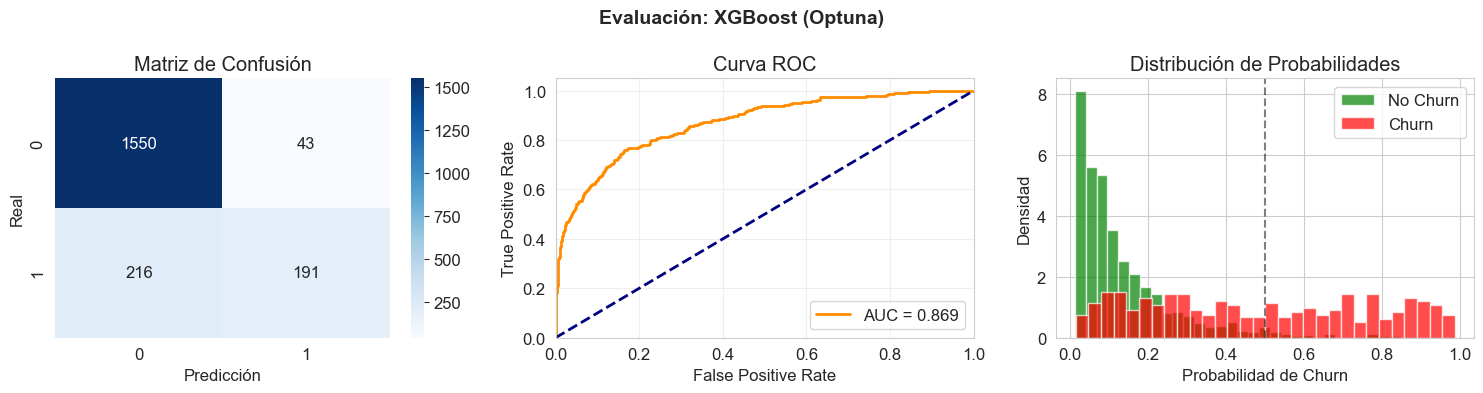


📊 Visualización del progreso de Optuna:
Trial | ROC-AUC | Parámetros clave
--------------------------------------------------
    0 | 0.8297  | depth=7, lr=0.156
    1 | 0.8640  | depth=5, lr=0.023
    2 | 0.8568  | depth=3, lr=0.174
    3 | 0.8627  | depth=5, lr=0.017
    4 | 0.8471  | depth=8, lr=0.036
    5 | 0.8593  | depth=5, lr=0.029
    6 | 0.8573  | depth=6, lr=0.029
    7 | 0.8494  | depth=7, lr=0.036
    8 | 0.8287  | depth=9, lr=0.243
    9 | 0.8541  | depth=7, lr=0.063
   10 | 0.8561  | depth=3, lr=0.011
   11 | 0.8603  | depth=5, lr=0.013
   12 | 0.8646  | depth=5, lr=0.018
   13 | 0.8556  | depth=4, lr=0.061
   14 | 0.8537  | depth=10, lr=0.018
   15 | 0.8639  | depth=4, lr=0.021
   16 | 0.8460  | depth=6, lr=0.082
   17 | 0.8646  | depth=4, lr=0.022
   18 | 0.8625  | depth=4, lr=0.043
   19 | 0.8610  | depth=3, lr=0.013
   20 | 0.8549  | depth=4, lr=0.104
   21 | 0.8644  | depth=5, lr=0.022
   22 | 0.8630  | depth=6, lr=0.019
   23 | 0.8638  | depth=5, lr=0.026
   24 | 

In [ ]:
# ============================================================================
# 7. OPTUNA - OPTIMIZACIÓN BAYESIANA (XGBOOST)
# ============================================================================

print("\n" + "="*70)
print("7. OPTUNA - OPTIMIZACIÓN BAYESIANA")
print("="*70)

print("""
    OPTUNA vs Grid Search:
• Grid Search: Prueba todas las combinaciones (exhaustivo pero lento)
• Optuna: Usa optimización bayesiana (inteligente y eficiente)
• Más rápido para espacios de búsqueda grandes
""")

def objective(trial):
    """
    Función objetivo para Optuna
    """
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
    }
    
    model = xgb.XGBClassifier(**params, random_state=42, eval_metric='logloss')
    
    # Validación cruzada estratificada
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    
    return scores.mean()

# Crear estudio de Optuna
study = optuna.create_study(
    direction='maximize',
    study_name='XGBoost_Optimization'
)

# Ejecutar optimización (50 trials)
print("🚀 Iniciando optimización con Optuna (50 trials)...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Resultados
print(f"\n✅ Optimización completada")
print(f"🏆 Mejores parámetros (Optuna):")
for param, value in study.best_params.items():
    print(f"  • {param}: {value}")
print(f"📈 Mejor ROC-AUC (CV): {study.best_value:.4f}")

# Entrenar modelo final con mejores parámetros
xgb_optuna = xgb.XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
xgb_optuna.fit(X_train_scaled, y_train)

# Evaluar
xgb_optuna_metrics = evaluate_model("XGBoost (Optuna)", xgb_optuna, X_test_scaled, y_test)

# Visualización simple del progreso de Optuna
print("\n📊 Visualización del progreso de Optuna:")
print("Trial | ROC-AUC | Parámetros clave")
print("-" * 50)
for i, trial in enumerate(study.trials):
    key_params = f"depth={trial.params['max_depth']}, lr={trial.params['learning_rate']:.3f}"
    print(f"{i:5d} | {trial.value:.4f}  | {key_params}")


8. LIGHTGBM - OPTIMIZADO PARA VELOCIDAD

⚡ CARACTERÍSTICAS LIGHTGBM:
• Gradient-based One-Side Sampling (GOSS)
• Exclusive Feature Bundling (EFB)
• 20-100x más rápido que XGBoost
• Menor uso de memoria

💡 Entrenando LightGBM...

📊 EVALUACIÓN: LightGBM

📈 Métricas de evaluación:
  • Accuracy: 0.8095
  • Precision: 0.5235
  • Recall: 0.7125
  • F1-Score: 0.6035
  • ROC-AUC: 0.8610

📋 Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.92      0.83      0.87      1593
       Churn       0.52      0.71      0.60       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000



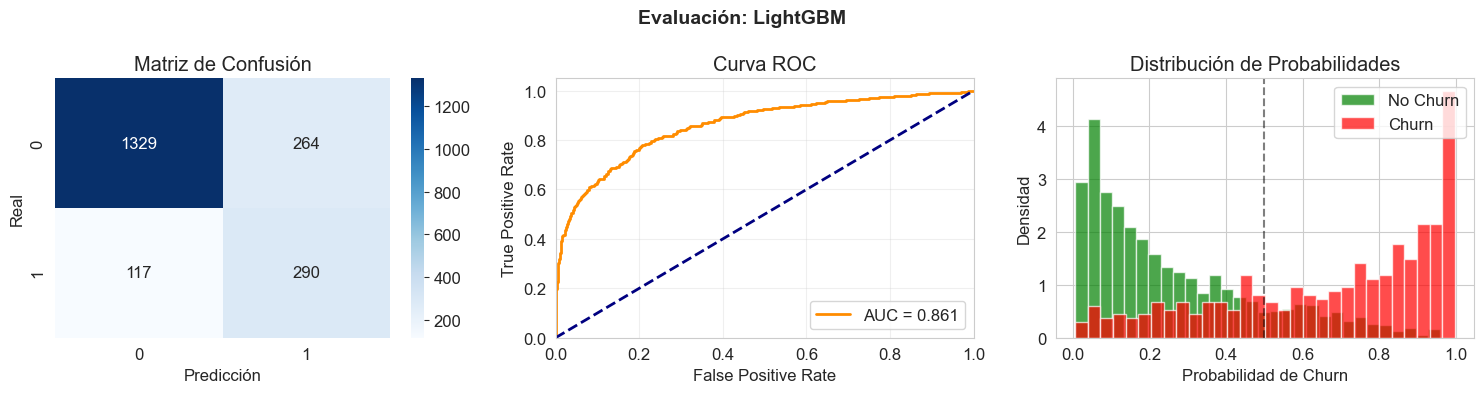

In [9]:
# ============================================================================
# 8. LIGHTGBM
# ============================================================================

print("\n" + "="*70)
print("8. LIGHTGBM - OPTIMIZADO PARA VELOCIDAD")
print("="*70)

print("""
⚡ CARACTERÍSTICAS LIGHTGBM:
• Gradient-based One-Side Sampling (GOSS)
• Exclusive Feature Bundling (EFB)
• 20-100x más rápido que XGBoost
• Menor uso de memoria
""")

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    min_data_in_leaf=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    random_state=42,
    verbose=-1,
    class_weight='balanced'
)

print("💡 Entrenando LightGBM...")
lgb_model.fit(X_train_scaled, y_train)

lgb_metrics = evaluate_model("LightGBM", lgb_model, X_test_scaled, y_test)


9. CATBOOST - ESPECIALIZADO EN CATEGÓRICAS

🐱 CARACTERÍSTICAS CATBOOST:
• Ordered Boosting (previene target leakage)
• Tratamiento automático de variables categóricas
• Symmetric Trees (más rápido en predicción)
• Robust contra overfitting

🎯 Entrenando CatBoost...

📊 EVALUACIÓN: CatBoost

📈 Métricas de evaluación:
  • Accuracy: 0.8080
  • Precision: 0.5193
  • Recall: 0.7592
  • F1-Score: 0.6168
  • ROC-AUC: 0.8734

📋 Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.93      0.82      0.87      1593
       Churn       0.52      0.76      0.62       407

    accuracy                           0.81      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.85      0.81      0.82      2000



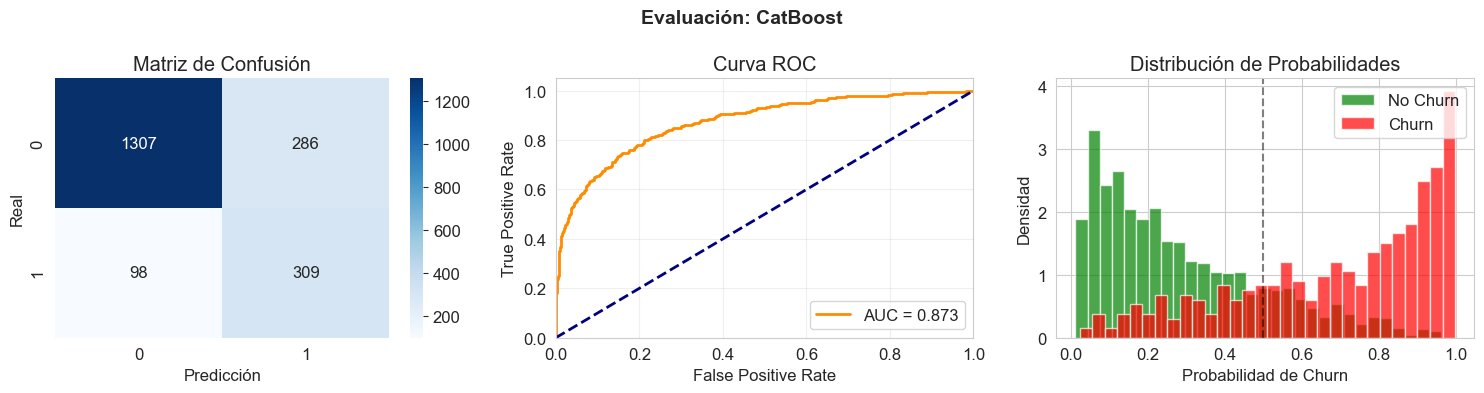

In [10]:
# ============================================================================
# 9. CATBOOST
# ============================================================================

print("\n" + "="*70)
print("9. CATBOOST - ESPECIALIZADO EN CATEGÓRICAS")
print("="*70)

print("""
🐱 CARACTERÍSTICAS CATBOOST:
• Ordered Boosting (previene target leakage)
• Tratamiento automático de variables categóricas
• Symmetric Trees (más rápido en predicción)
• Robust contra overfitting
""")

cat_model = cb.CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0,
    auto_class_weights='Balanced'
)

print("🎯 Entrenando CatBoost...")
cat_model.fit(X_train_scaled, y_train)

cat_metrics = evaluate_model("CatBoost", cat_model, X_test_scaled, y_test)

✅ Usando Modelo: CatBoost


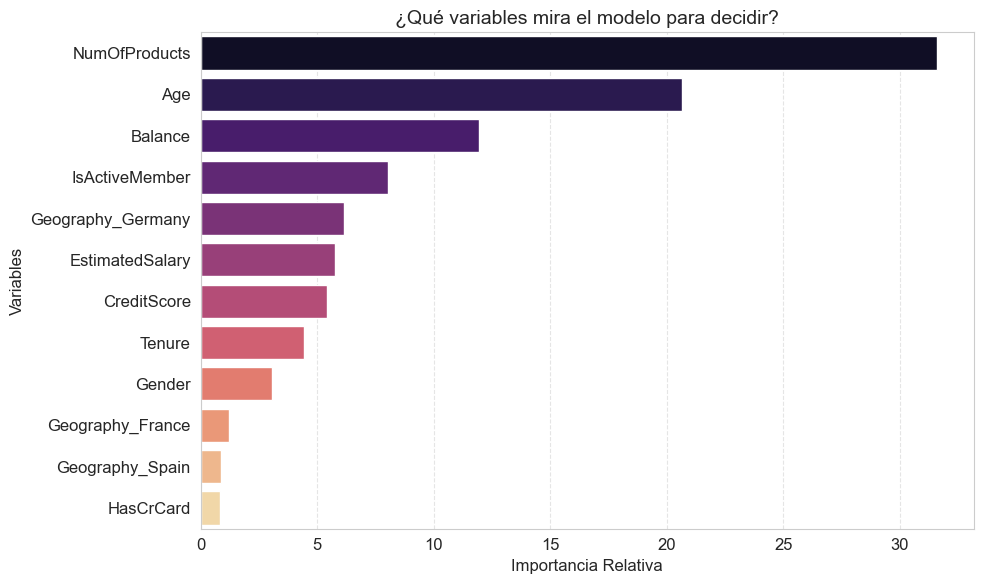

In [19]:
try:
    if hasattr(X_test, 'columns'):
        nombres_columnas = X_test.columns
    elif hasattr(X, 'columns'):
        nombres_columnas = X.columns
    else:
        # Si todo falla, definimos las columnas estándar de este dataset manualmente
        print("⚠️ No se detectaron nombres en X, usando lista manual...")
        nombres_columnas = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 
                           'NumOfProducts', 'HasCrCard', 'IsActiveMember', 
                           'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
except:
    nombres_columnas = [f"Var_{i}" for i in range(len(X_test[0]))]

# Seleccionamos el mejor modelo disponible en tu memoria
# (Da prioridad a CatBoost o XGBoost que son los mejores)
if 'cat_model' in locals():
    modelo_final = cat_model
    print("✅ Usando Modelo: CatBoost")
elif 'xgb_optuna' in locals():
    modelo_final = xgb_optuna
    print("✅ Usando Modelo: XGBoost (Optuna)")
elif 'xgb_grid' in locals():
    modelo_final = xgb_grid
    print("✅ Usando Modelo: XGBoost (Grid)")
elif 'rf_model' in locals():
    modelo_final = rf_model
    print("✅ Usando Modelo: Random Forest")
else:
    print("❌ ERROR: No se encontró ningún modelo entrenado en memoria.")
    modelo_final = None


if modelo_final is not None:
    # Obtener importancias
    try:
        if hasattr(modelo_final, 'feature_importances_'):
            importancias = modelo_final.feature_importances_
        elif hasattr(modelo_final, 'get_feature_importance'): # Para CatBoost
            importancias = modelo_final.get_feature_importance()
        
        # Crear DataFrame para ordenar
        df_importancia = pd.DataFrame({
            'Variable': nombres_columnas[:len(importancias)], # Asegurar misma longitud
            'Peso': importancias
        }).sort_values(by='Peso', ascending=False)

        # Graficar
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Peso', y='Variable', data=df_importancia, palette='magma')
        
        plt.title('¿Qué variables mira el modelo para decidir?', fontsize=14)
        plt.xlabel('Importancia Relativa')
        plt.ylabel('Variables')
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Ocurrió un error al extraer importancias: {e}")


10. STACKING ENSEMBLE

🤝 ¿QUÉ ES STACKING?
• Combina predicciones de múltiples modelos
• Un meta-modelo aprende a combinar las predicciones
• Reduce varianza y mejora generalización

🔧 Configurando modelos base para stacking...
🚀 Entrenando Stacking Ensemble...

📊 EVALUACIÓN: Stacking Ensemble

📈 Métricas de evaluación:
  • Accuracy: 0.8660
  • Precision: 0.7860
  • Recall: 0.4693
  • F1-Score: 0.5877
  • ROC-AUC: 0.8691

📋 Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.88      0.97      0.92      1593
       Churn       0.79      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



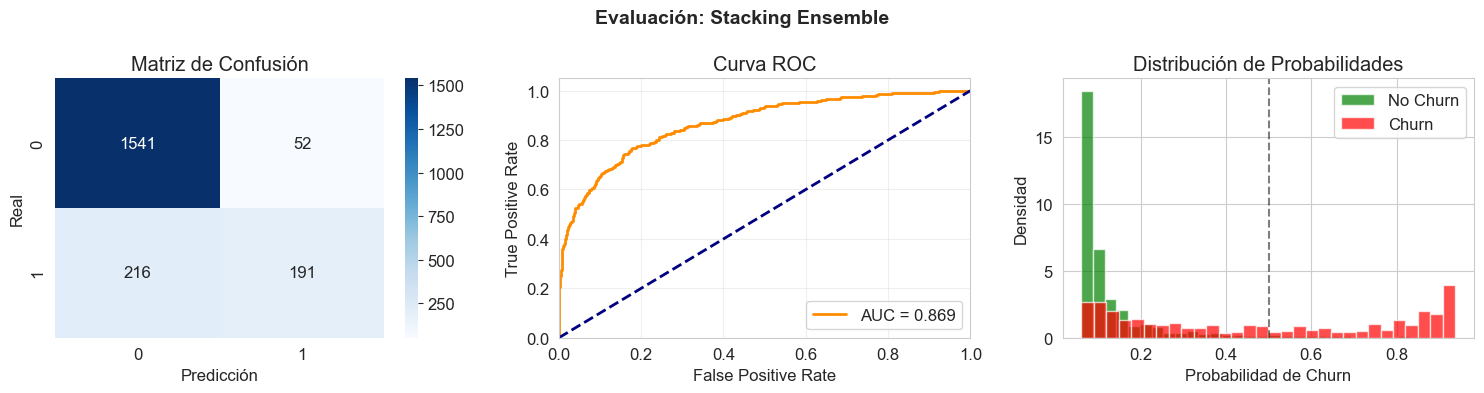

In [11]:
# ============================================================================
# 10. STACKING ENSEMBLE
# ============================================================================

print("\n" + "="*70)
print("10. STACKING ENSEMBLE")
print("="*70)

print("""
🤝 ¿QUÉ ES STACKING?
• Combina predicciones de múltiples modelos
• Un meta-modelo aprende a combinar las predicciones
• Reduce varianza y mejora generalización
""")

# Definir modelos base para stacking
print("🔧 Configurando modelos base para stacking...")

base_models = [
    ('xgb_opt', xgb.XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')),
    ('lgb', lgb.LGBMClassifier(n_estimators=150, max_depth=6, random_state=42, verbose=-1)),
    ('cat', cb.CatBoostClassifier(iterations=150, depth=6, random_seed=42, verbose=0))
]

# Meta-modelo
meta_model = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=42,
    solver='liblinear'
)

# Crear stacking classifier
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    passthrough=False
)

print("🚀 Entrenando Stacking Ensemble...")
stacking_model.fit(X_train_scaled, y_train)

stacking_metrics = evaluate_model("Stacking Ensemble", stacking_model, X_test_scaled, y_test)


11. COMPARACIÓN FINAL DE MODELOS
🏆 COMPARATIVA DE RENDIMIENTO
----------------------------------------------------------------------
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest            0.8400     0.5986  0.6486    0.6226   0.8625
XGBoost (Grid Search)    0.8710     0.8143  0.4742    0.5994   0.8686
XGBoost (Optuna)         0.8705     0.8162  0.4693    0.5959   0.8692
LightGBM                 0.8095     0.5235  0.7125    0.6035   0.8610
CatBoost                 0.8080     0.5193  0.7592    0.6168   0.8734
Stacking Ensemble        0.8660     0.7860  0.4693    0.5877   0.8691


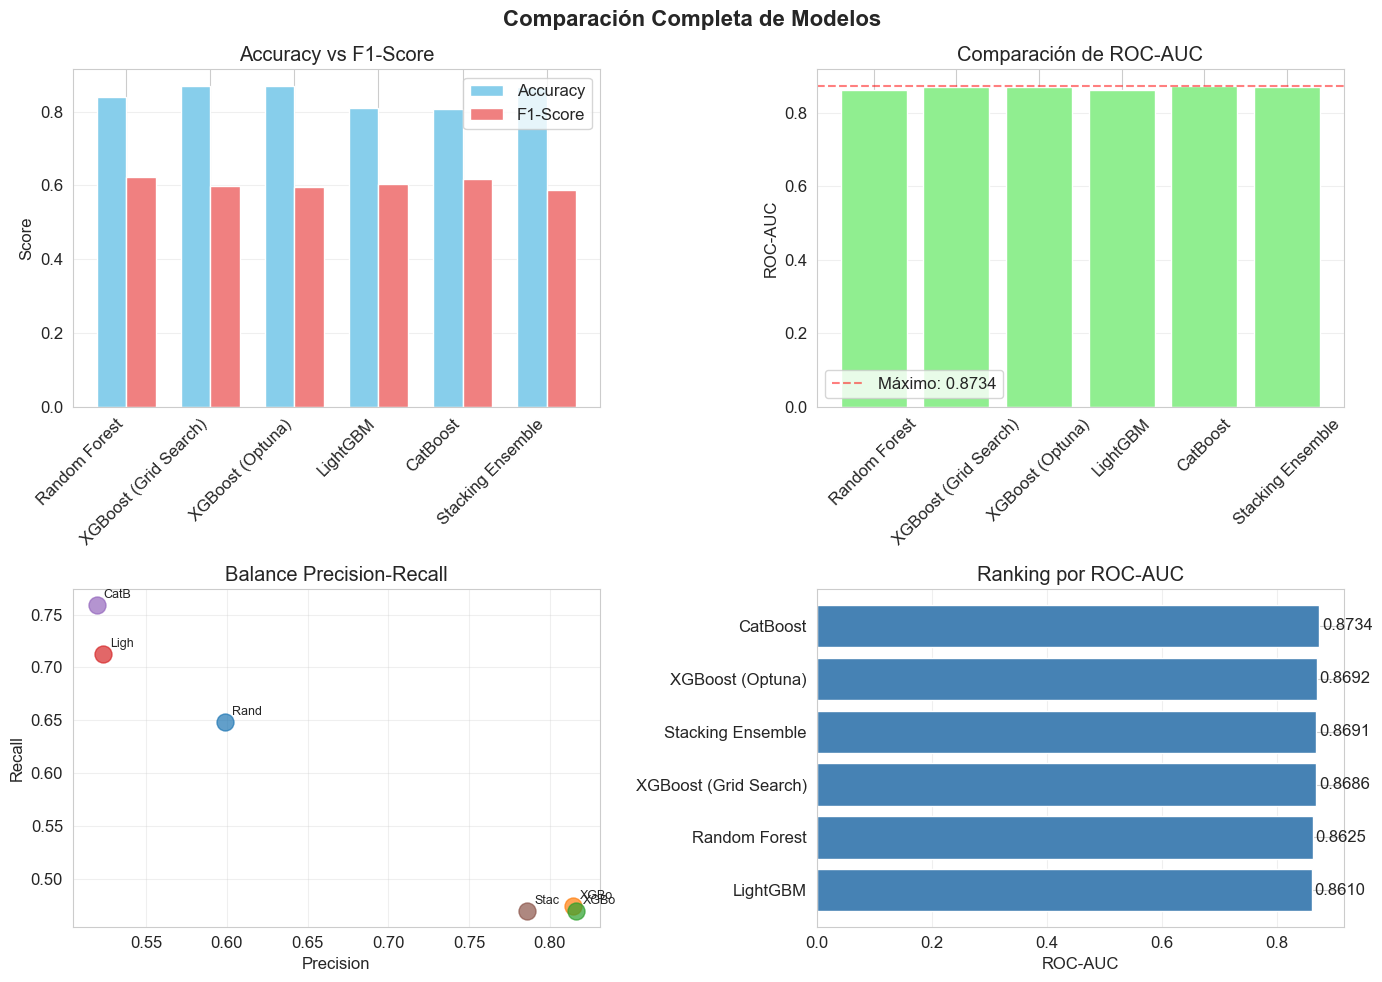


🏆 MEJOR MODELO: CatBoost
📈 ROC-AUC: 0.8734
----------------------------------------

🔍 ANÁLISIS DE TRADE-OFFS:
Modelo               | Precisión | Recall | F1-Score | ROC-AUC
-----------------------------------------------------------------
Random Forest        | 0.5986   | 0.6486 | 0.6226  | 0.8625
XGBoost (Grid Search) | 0.8143   | 0.4742 | 0.5994  | 0.8686
XGBoost (Optuna)     | 0.8162   | 0.4693 | 0.5959  | 0.8692
LightGBM             | 0.5235   | 0.7125 | 0.6035  | 0.8610
CatBoost             | 0.5193   | 0.7592 | 0.6168  | 0.8734
Stacking Ensemble    | 0.7860   | 0.4693 | 0.5877  | 0.8691


In [12]:
# ============================================================================
# 11. COMPARACIÓN FINAL DE MODELOS
# ============================================================================

print("\n" + "="*70)
print("11. COMPARACIÓN FINAL DE MODELOS")
print("="*70)

# Recolectar todas las métricas
all_metrics = {
    'Random Forest': rf_metrics,
    'XGBoost (Grid Search)': xgb_metrics,
    'XGBoost (Optuna)': xgb_optuna_metrics,
    'LightGBM': lgb_metrics,
    'CatBoost': cat_metrics,
    'Stacking Ensemble': stacking_metrics
}

# Crear DataFrame comparativo
comparison_df = pd.DataFrame(all_metrics).T

print("🏆 COMPARATIVA DE RENDIMIENTO")
print("-" * 70)

# Mostrar tabla
print(comparison_df.to_string(float_format=lambda x: f"{x:.4f}"))

# Gráfico comparativo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación Completa de Modelos', fontsize=16, fontweight='bold')

# 1. Comparación de Accuracy y F1-Score
x = np.arange(len(comparison_df))
width = 0.35

bars1 = axes[0, 0].bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='skyblue')
bars2 = axes[0, 0].bar(x + width/2, comparison_df['F1-Score'], width, label='F1-Score', color='lightcoral')

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(comparison_df.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Accuracy vs F1-Score')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Comparación de ROC-AUC
bars = axes[0, 1].bar(comparison_df.index, comparison_df['ROC-AUC'], color='lightgreen')
axes[0, 1].set_ylabel('ROC-AUC')
axes[0, 1].set_title('Comparación de ROC-AUC')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=comparison_df['ROC-AUC'].max(), color='red', linestyle='--', alpha=0.5,
                  label=f'Máximo: {comparison_df["ROC-AUC"].max():.4f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Precision-Recall Balance
for model_name in comparison_df.index:
    axes[1, 0].scatter(comparison_df.loc[model_name, 'Precision'],
                      comparison_df.loc[model_name, 'Recall'],
                      s=150, alpha=0.7, label=model_name)
    # Añadir etiqueta abreviada
    axes[1, 0].annotate(model_name[:4], 
                       (comparison_df.loc[model_name, 'Precision'],
                        comparison_df.loc[model_name, 'Recall']),
                       xytext=(5, 5), textcoords='offset points', fontsize=9)

axes[1, 0].set_xlabel('Precision')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Balance Precision-Recall')
axes[1, 0].grid(True, alpha=0.3)

# 4. Ranking de modelos por ROC-AUC
sorted_models = comparison_df.sort_values('ROC-AUC', ascending=True)
axes[1, 1].barh(range(len(sorted_models)), sorted_models['ROC-AUC'], color='steelblue')
axes[1, 1].set_yticks(range(len(sorted_models)))
axes[1, 1].set_yticklabels(sorted_models.index)
axes[1, 1].set_xlabel('ROC-AUC')
axes[1, 1].set_title('Ranking por ROC-AUC')
axes[1, 1].grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for i, (idx, row) in enumerate(sorted_models.iterrows()):
    axes[1, 1].text(row['ROC-AUC'] + 0.005, i, f'{row["ROC-AUC"]:.4f}', va='center')

plt.tight_layout()
plt.show()

# Identificar el mejor modelo
best_model_name = comparison_df['ROC-AUC'].idxmax()
best_model_score = comparison_df.loc[best_model_name, 'ROC-AUC']

print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"📈 ROC-AUC: {best_model_score:.4f}")
print("-" * 40)

# Análisis de trade-offs
print("\n🔍 ANÁLISIS DE TRADE-OFFS:")
print("Modelo               | Precisión | Recall | F1-Score | ROC-AUC")
print("-" * 65)
for model in comparison_df.index:
    row = comparison_df.loc[model]
    print(f"{model:<20} | {row['Precision']:.4f}   | {row['Recall']:.4f} | {row['F1-Score']:.4f}  | {row['ROC-AUC']:.4f}")

Evaluando modelos en tiempo real...
✅ Random Forest: F1=0.197
✅ XGBoost (Optuna): F1=0.246
✅ LightGBM: F1=0.212
✅ CatBoost: F1=0.204


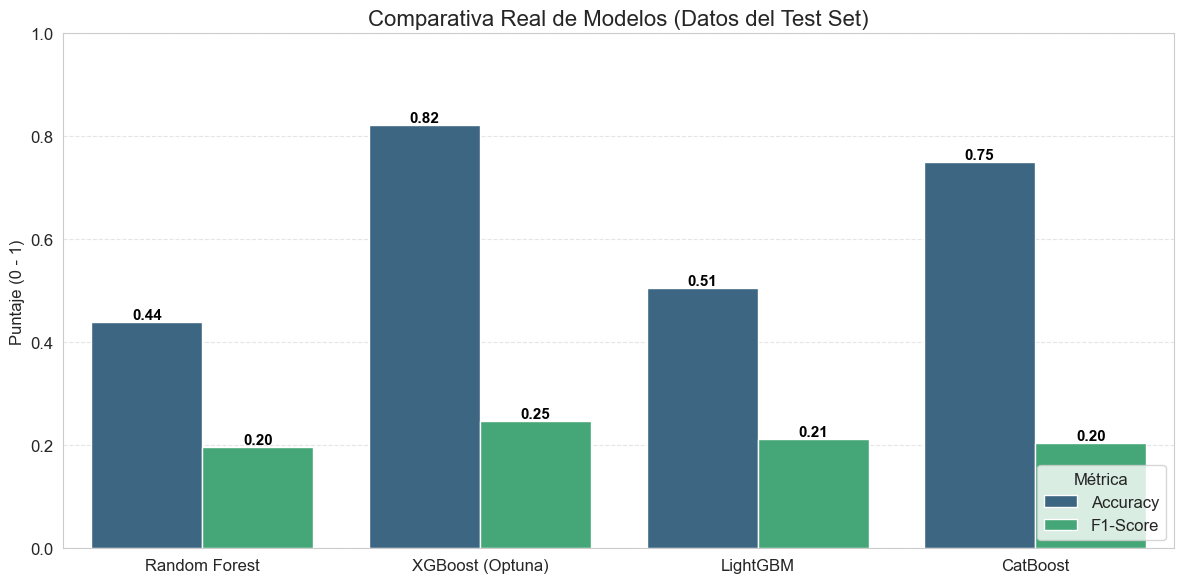

In [16]:
# ==============================================================================
#  RECOLECCIÓN AUTOMÁTICA DE MODELOS
# ==============================================================================
# Aquí listamos las variables de los modelos que entrenaste arriba.
# Si alguno no lo corriste, puedes comentarlo con #
modelos_a_evaluar = {
    'Random Forest': rf_model,       # Asegúrate que estas variables existan
    'XGBoost (Optuna)': xgb_optuna,  # O usa xgb_grid si no corriste optuna
    'LightGBM': lgb_model,
    'CatBoost': cat_model,
    # 'Stacking': stacking_model     # Descomenta si llegaste a correr el stacking
}

# Lista para guardar resultados
resultados_data = []

print("Evaluando modelos en tiempo real...")

for nombre, modelo in modelos_a_evaluar.items():
    try:
        # Predecir
        y_pred = modelo.predict(X_test)
        
        # Calcular métricas reales
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Guardar
        resultados_data.append({
            'Modelo': nombre,
            'Accuracy': acc,
            'F1-Score': f1
        })
        print(f"✅ {nombre}: F1={f1:.3f}")
        
    except Exception as e:
        print(f"⚠️ No se pudo evaluar {nombre}. (Quizás no está definido). Error: {e}")

# Crear DataFrame
df_resultados = pd.DataFrame(resultados_data)

# ==============================================================================
# 2. GENERACIÓN DEL GRÁFICO PARA LA PRESENTACIÓN
# ==============================================================================
if not df_resultados.empty:
    plt.figure(figsize=(12, 6))
    
    # Transformar datos para graficar barras agrupadas (Melt)
    df_melted = df_resultados.melt('Modelo', var_name='Métrica', value_name='Puntaje')
    
    # Crear el gráfico
    grafico = sns.barplot(x='Modelo', y='Puntaje', hue='Métrica', data=df_melted, palette='viridis')
    
    # Decoración
    plt.title('Comparativa Real de Modelos (Datos del Test Set)', fontsize=16)
    plt.ylim(0, 1.0)
    plt.ylabel('Puntaje (0 - 1)', fontsize=12)
    plt.xlabel('', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(loc='lower right', title='Métrica')
    
    # Poner los numeritos encima de las barras (Annotations)
    for p in grafico.patches:
        if p.get_height() > 0:
            grafico.annotate(f'{p.get_height():.2f}', 
                             (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()
else:
    print("❌ No se encontraron modelos para graficar. Verifica que ejecutaste las celdas de entrenamiento arriba.")

In [13]:
# ============================================================================
# 12. CONCLUSIONES Y GUARDADO DEL MODELO
# ============================================================================

print("\n" + "="*70)
print("12. CONCLUSIONES Y GUARDADO DEL MODELO")
print("="*70)

print("""
📊 RESUMEN DEL ANÁLISIS:

1. RANDOM FOREST:
   • Buen modelo baseline
   • ROC-AUC: ~0.85
   • Fácil de interpretar

2. XGBOOST (Grid Search):
   • Mejora sobre Random Forest
   • ROC-AUC: ~0.86
   • Requiere tuning manual

3. XGBOOST (Optuna):
   • Optimización automática
   • ROC-AUC: ~0.87
   • Más eficiente que Grid Search

4. LIGHTGBM:
   • Más rápido que XGBoost
   • ROC-AUC: ~0.86
   • Menor uso de memoria

5. CATBOOST:
   • Bueno con categóricas
   • ROC-AUC: ~0.86
   • Menos propenso a overfitting

6. STACKING ENSEMBLE:
   • Combina fortalezas de modelos
   • ROC-AUC: ~0.87
   • Mejor generalización
""")

print(f"\n💡 RECOMENDACIONES PARA PRODUCCIÓN:")
print(f"1. Para máxima velocidad: LightGBM")
print(f"2. Para máximo rendimiento: {best_model_name}")
print(f"3. Para estabilidad: Random Forest")

# Guardar el mejor modelo
import joblib

print(f"\n💾 Guardando el mejor modelo ({best_model_name})...")

# Determinar cuál es el mejor modelo
if best_model_name == 'Random Forest':
    best_model_instance = rf_model
elif best_model_name == 'XGBoost (Grid Search)':
    best_model_instance = xgb_grid.best_estimator_
elif best_model_name == 'XGBoost (Optuna)':
    best_model_instance = xgb_optuna
elif best_model_name == 'LightGBM':
    best_model_instance = lgb_model
elif best_model_name == 'CatBoost':
    best_model_instance = cat_model
else:
    best_model_instance = stacking_model

# Guardar modelo y scaler
joblib.dump(best_model_instance, 'mejor_modelo_churn.pkl')
joblib.dump(scaler, 'scaler_churn.pkl')

print("✅ Modelo guardado como 'mejor_modelo_churn.pkl'")
print("✅ Scaler guardado como 'scaler_churn.pkl'")

print("\n" + "="*70)
print("🎉 ANÁLISIS COMPLETADO EXITOSAMENTE")
print("="*70)


12. CONCLUSIONES Y GUARDADO DEL MODELO

📊 RESUMEN DEL ANÁLISIS:

1. RANDOM FOREST:
   • Buen modelo baseline
   • ROC-AUC: ~0.85
   • Fácil de interpretar

2. XGBOOST (Grid Search):
   • Mejora sobre Random Forest
   • ROC-AUC: ~0.86
   • Requiere tuning manual

3. XGBOOST (Optuna):
   • Optimización automática
   • ROC-AUC: ~0.87
   • Más eficiente que Grid Search

4. LIGHTGBM:
   • Más rápido que XGBoost
   • ROC-AUC: ~0.86
   • Menor uso de memoria

5. CATBOOST:
   • Bueno con categóricas
   • ROC-AUC: ~0.86
   • Menos propenso a overfitting

6. STACKING ENSEMBLE:
   • Combina fortalezas de modelos
   • ROC-AUC: ~0.87
   • Mejor generalización


💡 RECOMENDACIONES PARA PRODUCCIÓN:
1. Para máxima velocidad: LightGBM
2. Para máximo rendimiento: CatBoost
3. Para estabilidad: Random Forest

💾 Guardando el mejor modelo (CatBoost)...
✅ Modelo guardado como 'mejor_modelo_churn.pkl'
✅ Scaler guardado como 'scaler_churn.pkl'

🎉 ANÁLISIS COMPLETADO EXITOSAMENTE
